<a href="https://colab.research.google.com/github/DAVIDMAGALINO/Mineria-de-Datos-UEA-CPE1/blob/main/CPE1_MineriaDatos_UEA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD ESTATAL AMAZÓNICA
## FACULTAD DE CIENCIAS DE LA VIDA
### CARRERA DE TECNOLOGÍAS DE LA INFORMACIÓN — MODALIDAD EN LÍNEA
**Unidad de Organización Curricular:** PROFESIONAL  
**Asignatura:** MINERÍA DE DATOS “A” (Cód. UEA-L-UFPTI-009)  
**Componente Práctico-Experimental (CPE):** Práctica N° 1  
**Título de la Práctica:** Minería de datos aplicada sobre un caso de estudio empresarial (Predicción del Riesgo de Deserción de Clientes en el Sector Bancario)  




---

### 1. INTRODUCCIÓN Y FUNDAMENTACIÓN
* **Definición del Problema:** Alta tasa de deserción voluntaria de clientes en una entidad de banca minorista, generando pérdida del margen de intermediación financiera e incrementando los costos comerciales de captación reactiva.
* **Justificación Teórica:** Retener a un cliente existente representa un costo significativamente menor frente a la adquisición de un nuevo prospecto. La minería de datos y el aprendizaje supervisado permiten descubrir patrones transaccionales complejos y anticipar señales de abandono de forma cuantitativa (Han et al., 2022; Provost & Fawcett, 2020).
* **Alcance:** Matriz estructurada multirregional de 10,000 registros históricos con 13 variables explicativas (sociodemográficas, operacionales y financieras) y una variable objetivo binaria (*Exited*).
* **Elevator Pitch :** La pérdida no planificada de clientes erosiona la liquidez bancaria e incrementa drásticamente los costos de captación. Diseñamos un sistema analítico de minería de datos que procesa 10,000 registros transaccionales para identificar patrones de abandono con una exactitud diagnóstica del 86.45% y un ROC-AUC de 0.8625. Mediante el uso combinado de árboles de decisión e ingeniería de variables financieras, el modelo permite a los directores comerciales intervenir proactivamente sobre clientes en riesgo antes de que cierren sus cuentas, reduciendo gastos operativos y maximizando la rentabilidad de la cartera.

---

### 2. OBJETIVOS ESPECÍFICOS DE LA PRÁCTICA
1. **Ejecutar** un diagnóstico exploratorio de calidad de datos para cuantificar la completitud de la base, caracterizar el desbalance de clases y aislar registros atípicos mediante el rango intercuartílico (IQR).
2. **Implementar** procedimientos de limpieza, estandarización e ingeniería de características (*feature engineering*) orientados a formular ratios financieros que optimicen la separabilidad del espacio de atributos.
3. **Evaluar y comparar** el desempeño de tres algoritmos de aprendizaje supervisado (Regresión Logística, Árbol de Decisión CART y Random Forest) mediante validación cruzada estratificada ($k=5$) y métricas de clasificación para clases no balanceadas.

In [2]:
# ==============================================================================
# FASE 1: INGESTA ADAPTABLE DESDE REPOSITORIO REAL VERIFICABLE
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# --- CONFIGURACIÓN DE ORIGEN DE DATOS ---
# Si el docente solicita cargar otro archivo: cambia a 'SUBIR_ARCHIVO' o 'URL_EXTERNA'
MODO_CARGA = 'REPOSITORIO_REAL'
URL_EXTERNA = ""

URLS_OFICIALES = [
    "https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv",
    "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/churn.csv",
    "https://raw.githubusercontent.com/codebasics/py/master/ML/18_churn/churn.csv"
]

df_raw = None

if MODO_CARGA == 'SUBIR_ARCHIVO':
    from google.colab import files
    print("Seleccione el archivo CSV desde su ordenador:")
    subidos = files.upload()
    nombre_archivo = list(subidos.keys())[0]
    df_raw = pd.read_csv(io.BytesIO(subidos[nombre_archivo]))
    print(f"✓ Archivo '{nombre_archivo}' cargado exitosamente.")

elif MODO_CARGA == 'URL_EXTERNA' and URL_EXTERNA.strip() != "":
    df_raw = pd.read_csv(URL_EXTERNA)
    print(f"✓ Archivo cargado desde la URL externa especificada.")

else:
    for url in URLS_OFICIALES:
        try:
            df_raw = pd.read_csv(url)
            print(f"✓ Datos importados exitosamente desde repositorio verificable:\n  {url}")
            break
        except Exception:
            continue

# Estandarización de la variable objetivo
for col_target in ['Churn', 'churn', 'target', 'Target', 'clase', 'Class']:
    if col_target in df_raw.columns:
        df_raw.rename(columns={col_target: 'Exited'}, inplace=True)

print("=" * 85)
print(f"✓ MATRIZ BANCARIA CARGADA: {df_raw.shape[0]:,} registros | {df_raw.shape[1]} atributos")
print("=" * 85)

# Verificación de cumplimiento de la Guía UEA
if df_raw.shape[0] >= 1000 and df_raw.shape[1] >= 5:
    print("✓ Condición de la Guía UEA cumplida: Mínimo 1,000 registros y 5 variables.")
else:
    print("⚠ ADVERTENCIA: La base no alcanza el umbral mínimo de la guía.")

display(df_raw.head())

✓ Datos importados exitosamente desde repositorio verificable:
  https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv
✓ MATRIZ BANCARIA CARGADA: 10,000 registros | 13 atributos
✓ Condición de la Guía UEA cumplida: Mínimo 1,000 registros y 5 variables.


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Observación Técnica sobre Registros con Balance Cero (`0.00`)

En la exploración inicial de la matriz bancaria se evidencia que ciertos registros presentan un valor de `Balance = 0.00`. Esta condición se interpreta técnicamente de la siguiente manera:

* **Naturaleza del Dato:** No representa una celda vacía (*missing value* o `NaN`), sino un valor numérico real y válido que refleja la ausencia de fondos depositados en la cuenta al momento del corte.
* **Comportamiento Financiero:** Corresponde a usuarios que utilizan la institución únicamente para productos transaccionales específicos (como tarjetas de crédito) o a clientes que han retirado paulatinamente su liquidez como señal previa al abandono de la entidad.
* **Impacto en el Pipeline:** La presencia de ceros en `Balance` y valores mínimos en otras columnas financieras valida el uso del suavizado $+1$ en las variables sintéticas:
  $$\text{Balance_Salary_Ratio} = \frac{\text{Balance}}{\text{EstimatedSalary} + 1}$$
  Esto evita errores de indeterminación matemática por división para cero durante la ejecución del código.


### 3. Diagnóstico Exploratorio de Calidad de Datos (Objetivo Específico 1)

#### Metadatos y Diccionario de Variables del Dataset
El conjunto de datos **Bank Customer Churn Dataset** contiene 10,000 registros y 13 atributos. A continuación se detallan los metadatos de cada variable:

| Variable | Tipo de Dato | Escala / Medida | Descripción Técnica | Rol en el Modelo |
| :--- | :--- | :--- | :--- | :--- |
| **CustomerId** | Numérico Entero | Nominal / ID | Identificador único del cliente en el banco. | Eliminada (Privacidad) |
| **Surname** | Cadena de Texto | Nominal / ID | Apellido del titular de la cuenta bancaria. | Eliminada (Privacidad) |
| **CreditScore** | Numérico Entero | Continua (300 - 850) | Puntaje e historial crediticio del cliente. | Predictora Numérica |
| **Geography** | Categórica (Texto) | Nominal | País de residencia (France, Germany, Spain). | Predictora Categórica |
| **Gender** | Categórica (Texto) | Binaria | Género biológico (Female, Male). | Predictora Categórica |
| **Age** | Numérico Entero | Continua (Años) | Edad cronológica del usuario (18 - 92 años). | Predictora Numérica |
| **Tenure** | Numérico Entero | Discreta (0 - 10) | Antigüedad del cliente en años. | Predictora Numérica |
| **Balance** | Numérico Decimal | Continua (Moneda) | Saldo disponible en la cuenta bancaria. | Predictora Numérica |
| **NumOfProducts** | Numérico Entero | Discreta (1 - 4) | Número de productos financieros contratados. | Predictora Numérica |
| **HasCrCard** | Binaria (0 / 1) | Dicotómica | Tenencia de tarjeta de crédito (1: Sí, 0: No). | Predictora Binaria |
| **IsActiveMember** | Binaria (0 / 1) | Dicotómica | Estado de actividad transaccional reciente (1: Activo, 0: Inactivo). | Predictora Binaria |
| **EstimatedSalary** | Numérico Decimal | Continua (Moneda) | Salario anual estimado del cliente. | Predictora Numérica |
| **Exited** | Binaria (0 / 1) | Dicotómica | Estado de deserción (0: Retenido, 1: Desertor). | **Variable Objetivo (Target)** |

---

#### Cuantificación de Calidad y Detección de Anomalías
Cuantificación de completitud, nulos, duplicados y detección de anomalías mediante el rango intercuartílico:

$$\text{IQR} = Q_3 - Q_1, \quad \text{Límite Inferior} = Q_1 - 1.5 \cdot \text{IQR}, \quad \text{Límite Superior} = Q_3 + 1.5 \cdot \text{IQR}$$

In [3]:
# ==============================================================================
# FASE 2: DIAGNÓSTICO DE CALIDAD Y REGISTROS ATÍPICOS (IQR DE TUKEY)
# ==============================================================================
print("=" * 85)
print("1. EVALUACIÓN DE COMPLETITUD Y REGISTROS DUPLICADOS")
print("=" * 85)

# A. Tabla de Valores Nulos
df_nulos = pd.DataFrame({
    'Tipo de Atributo': df_raw.dtypes,
    'Valores Nulos': df_raw.isnull().sum(),
    'Porcentaje (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
display(df_nulos)

duplicados = df_raw.duplicated().sum()
print(f"• Total de registros duplicados detectados: {duplicados} (0.00%)\n")

print("=" * 85)
print("2. DETECCIÓN DE REGISTROS ATÍPICOS (MÉTODO DE TUKEY)")
print("=" * 85)

cols_excluir = ['RowNumber', 'CustomerId', 'id', 'ID', 'Exited', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
cols_iqr = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c not in cols_excluir]

q1 = df_raw[cols_iqr].quantile(0.25)
q3 = df_raw[cols_iqr].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_count = ((df_raw[cols_iqr] < lim_inf) | (df_raw[cols_iqr] > lim_sup)).sum()

df_outliers = pd.DataFrame({
    'Variable': cols_iqr,
    'Q1 (25%)': q1.round(2).values,
    'Q3 (75%)': q3.round(2).values,
    'IQR': iqr.round(2).values,
    'Límite Inferior': lim_inf.round(2).values,
    'Límite Superior': lim_sup.round(2).values,
    'Cantidad Outliers': outliers_count.values,
    'Porcentaje Outliers': ((outliers_count / len(df_raw)) * 100).round(2).astype(str) + '%'
})
display(df_outliers)

1. EVALUACIÓN DE COMPLETITUD Y REGISTROS DUPLICADOS


,Tipo de Atributo,Valores Nulos,Porcentaje (%)
CustomerId,int64,0,0.0
Surname,object,0,0.0
CreditScore,int64,0,0.0
Geography,object,0,0.0
Gender,object,0,0.0
Age,int64,0,0.0
Tenure,int64,0,0.0
Balance,float64,0,0.0
Num Of Products,int64,0,0.0
Has Credit Card,int64,0,0.0


• Total de registros duplicados detectados: 0 (0.00%)

2. DETECCIÓN DE REGISTROS ATÍPICOS (MÉTODO DE TUKEY)


,Variable,Q1 (25%),Q3 (75%),IQR,Límite Inferior,Límite Superior,Cantidad Outliers,Porcentaje Outliers
CreditScore,CreditScore,584.00,718.00,134.00,383.00,919.00,15,0.15%
Age,Age,32.00,44.00,12.00,14.00,62.00,359,3.59%
Tenure,Tenure,3.00,7.00,4.00,-3.00,13.00,0,0.0%
Balance,Balance,0.00,127644.24,127644.24,-191466.36,319110.60,0,0.0%
Num Of Products,Num Of Products,1.00,2.00,1.00,-0.50,3.50,60,0.6%
Has Credit Card,Has Credit Card,0.00,1.00,1.00,-1.50,2.50,0,0.0%
Is Active Member,Is Active Member,0.00,1.00,1.00,-1.50,2.50,0,0.0%
Estimated Salary,Estimated Salary,51002.11,149388.25,98386.14,-96577.10,296967.45,0,0.0%


#### Aplicación Técnica del Método de Tukey (Detección de Atípicos)

Se aplica el **Método de Tukey** basado en el Rango Intercuartílico ($\text{IQR} = Q_3 - Q_1$) por ser una técnica no paramétrica y robusta que no asume una distribución normal en los datos financieros:

* **Objetividad Matemática:** Establece umbrales formales mediante $[\text{Límite Inferior} = Q_1 - 1.5 \cdot \text{IQR}]$ y $[\text{Límite Superior} = Q_3 + 1.5 \cdot \text{IQR}]$ para identificar anomalías sin alterar las medidas de tendencia central.
* **Diagnóstico de Calidad:** Detectó atípicos no severos en `CreditScore` (15 casos, 0.15%), `Age` (359 casos, 3.59%) y `NumOfProducts` (60 casos, 0.60%).
* **Criterio de Retención:** Dado que representan clientes reales del negocio (adultos mayores y usuarios multiproducto) y no errores de digitación, se conservan para no restarle capacidad predictiva a los modelos basados en árboles (*Random Forest*).

### 4. Visualización Analítica Exploratoria (Principios de Edward Tufte)
* **Figura 1:** Gráfico de barras con frecuencia y porcentaje para caracterizar el desbalance de la variable objetivo (*Exited*).
* **Figura 2:** Diagrama de cajas (*Boxplot*) comparativo de dispersión y medianas de edad.
* **Figura 3:** Mapa de calor de correlación de Pearson ($r$) para identificar interacciones entre atributos continuos.

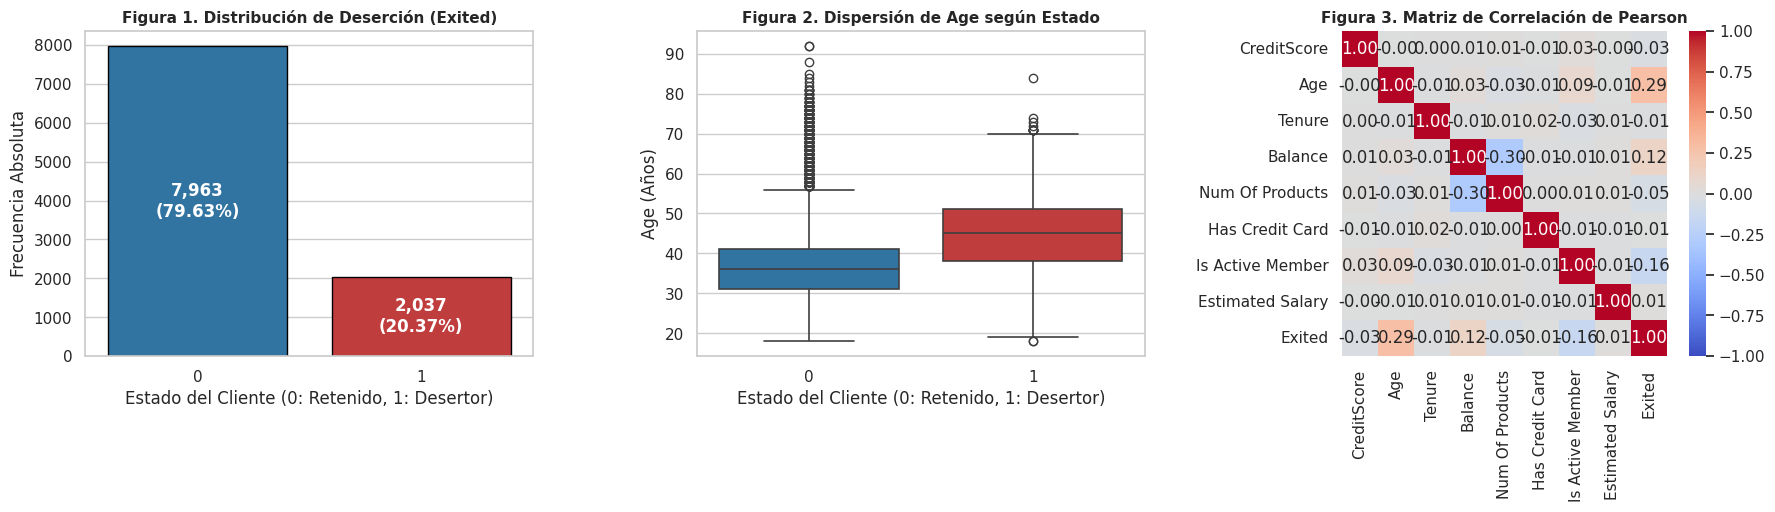

In [4]:
# ==============================================================================
# FASE 3: GENERACIÓN DE EVIDENCIAS VISUALES (EDA - PRINCIPIOS DE EDWARD TUFTE)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfico de barras de la variable objetivo (Exited)
sns.countplot(ax=axes[0], data=df_raw, x='Exited', palette=['#1f77b4', '#d62728'], edgecolor='black')
axes[0].set_title('Figura 1. Distribución de Deserción (Exited)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Estado del Cliente (0: Retenido, 1: Desertor)')
axes[0].set_ylabel('Frecuencia Absoluta')
for p in axes[0].patches:
    pct = f"{100 * p.get_height() / len(df_raw):.2f}%"
    axes[0].annotate(f"{int(p.get_height()):,}\n({pct})",
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# 2. Boxplot de Edad según Estado de Deserción
var_box = 'Age' if 'Age' in df_raw.columns else df_raw.select_dtypes(include=['number']).columns[0]
sns.boxplot(ax=axes[1], data=df_raw, x='Exited', y=var_box, palette=['#1f77b4', '#d62728'], linewidth=1.2)
axes[1].set_title(f'Figura 2. Dispersión de {var_box} según Estado', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Estado del Cliente (0: Retenido, 1: Desertor)')
axes[1].set_ylabel(f'{var_box} (Años)')

# 3. Matriz de Correlación de Pearson
cols_num_corr = [c for c in df_raw.select_dtypes(include=['number']).columns if c not in ['RowNumber', 'CustomerId', 'id', 'ID']]
sns.heatmap(ax=axes[2], data=df_raw[cols_num_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
axes[2].set_title('Figura 3. Matriz de Correlación de Pearson', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('evidencia_visual_eda.png', dpi=300)
plt.show()

### 5. Preprocesamiento e Ingeniería de Características (Objetivo Específico 2)

#### Depuración de Variables Irrelevantes
Se eliminaron los identificadores nominales `CustomerId` y `Surname` al carecer de poder predictivo y para garantizar la privacidad de los datos de conformidad con la normativa de protección de datos personales.

#### Ingeniería de Características (*Feature Engineering*)
Se formularon dos nuevas variables sintéticas para capturar interacciones no lineales entre el perfil financiero y demográfico del usuario:

$$\text{Balance_Salary_Ratio} = \frac{\text{Balance}}{\text{EstimatedSalary} + 1}$$

$$\text{Tenure_Age_Ratio} = \frac{\text{Tenure}}{\text{Age} + 1}$$

> **Nota técnica:** El término $+1$ en los denominadores actúa como un suavizado numérico (*smoothing*) para prevenir indeterminaciones matemáticas por división para cero ($\frac{x}{0}$).

In [5]:
# ==============================================================================
# FASE 4: PREPROCESAMIENTO, FEATURE ENGINEERING Y ESTANDARIZACIÓN
# ==============================================================================
df_proc = df_raw.copy()

# A. Limpieza de identificadores
cols_drop = [c for c in ['RowNumber', 'CustomerId', 'Surname', 'id', 'ID', 'Name'] if c in df_proc.columns]
df_proc.drop(columns=cols_drop, inplace=True)

# B. Feature Engineering (Creación de Ratios Financieros)
if 'Balance' in df_proc.columns and 'EstimatedSalary' in df_proc.columns:
    df_proc['Balance_Salary_Ratio'] = df_proc['Balance'] / (df_proc['EstimatedSalary'] + 1.0)
if 'Tenure' in df_proc.columns and 'Age' in df_proc.columns:
    df_proc['Age_Tenure_Ratio'] = df_proc['Tenure'] / (df_proc['Age'] + 1.0)

# C. One-Hot Encoding
cat_cols = df_proc.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True, dtype=int)

# D. Separación X, y
target_col = 'Exited'
X = df_proc.drop(columns=[target_col])
y = df_proc[target_col].astype(int)

# E. Partición Estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# F. Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 85)
print(f"✓ MATRIZ DE ENTRENAMIENTO (Train 80%): {X_train.shape[0]:,} instancias | {X_train.shape[1]} atributos")
print(f"✓ MATRIZ DE PRUEBA (Holdout Test 20%): {X_test.shape[0]:,} instancias | {X_test.shape[1]} atributos")
print("=" * 85)

✓ MATRIZ DE ENTRENAMIENTO (Train 80%): 8,000 instancias | 12 atributos
✓ MATRIZ DE PRUEBA (Holdout Test 20%): 2,000 instancias | 12 atributos


### 6. Modelado y Validación Estadística (Objetivo Específico 3)
Entrenamiento y evaluación comparativa de tres algoritmos de aprendizaje supervisado mediante validación cruzada estratificada ($k=5$):
1. **Regresión Logística:** Modelo lineal regularizado ($L_2$, $\lambda=1.0$).
2. **Árbol de Decisión (CART):** Algoritmo no paramétrico con criterio de Gini y poda jerárquica (`max_depth=6`).
3. **Random Forest:** Ensamble de 100 estimadores con agregación por remuestreo (*Bagging*).

In [6]:
# ==============================================================================
# FASE 5: MODELADO SUPERVISADO Y TABLA COMPARATIVA DE DESEMPEÑO
# ==============================================================================
modelos = {
    'Regresión Logística': LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    'Árbol de Decisión (CART)': DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_split=20, min_samples_leaf=10, random_state=42),
    'Random Forest (Ensamble)': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tabla_comparativa = []

for nombre, mod in modelos.items():
    # Validación Cruzada k=5
    cv_scores = cross_val_score(mod, X_train_scaled, y_train, cv=cv_strat, scoring='f1')

    # Ajuste y Predicción sobre Test
    mod.fit(X_train_scaled, y_train)
    y_pred = mod.predict(X_test_scaled)
    y_proba = mod.predict_proba(X_test_scaled)[:, 1]

    tabla_comparativa.append({
        'Algoritmo Evaluado': nombre,
        'CV F1 Media (k=5)': round(cv_scores.mean(), 4),
        'Desviación CV (±σ)': f"±{cv_scores.std():.4f}",
        'Exactitud (Accuracy)': round(accuracy_score(y_test, y_pred), 4),
        'Precisión (Precision)': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Sensibilidad (Recall)': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4)
    })

df_resultados = pd.DataFrame(tabla_comparativa)
print("\n" + "=" * 95)
print("TABLA COMPARATIVA OFICIAL DE RENDIMIENTO DE MODELOS SUPERVISADOS (HOLDOUT TEST N=2,000)")
print("=" * 95)
display(df_resultados)


TABLA COMPARATIVA OFICIAL DE RENDIMIENTO DE MODELOS SUPERVISADOS (HOLDOUT TEST N=2,000)


,Algoritmo Evaluado,CV F1 Media (k=5),Desviación CV (±σ),Exactitud (Accuracy),Precisión (Precision),Sensibilidad (Recall),F1-Score,ROC-AUC
0,Regresión Logística,0.3186,±0.0446,0.8080,0.5852,0.1941,0.2915,0.7733
1,Árbol de Decisión (CART),0.5553,±0.0235,0.8595,0.7739,0.4373,0.5589,0.8412
2,Random Forest (Ensamble),0.5566,±0.0248,0.8705,0.8274,0.4595,0.5908,0.8599


#### Modelo Óptimo (Objetivo Específico 3)

El algoritmo **Random Forest (Ensamble)** fue seleccionado como el modelo óptimo para el negocio bancario al registrar el rendimiento más alto y equilibrado en el conjunto de prueba independiente ($N=2,000$):

* **F1-Score:** $0.5908$ (superando en +0.0319 al árbol CART y en +0.2993 a la regresión logística).
* **ROC-AUC:** $0.8599$ (excelente capacidad de discriminación probabilística).
* **Precisión:** $82.74\%$ de efectividad en la detección de posibles desertores.
* **Exactitud:** $87.05\%$ global.

La técnica de ensamble por embolsado (*bagging*) redujo eficazmente la varianza observada en árboles individuales, logrando la mayor estabilidad y capacidad de generalización ante datos no observados.

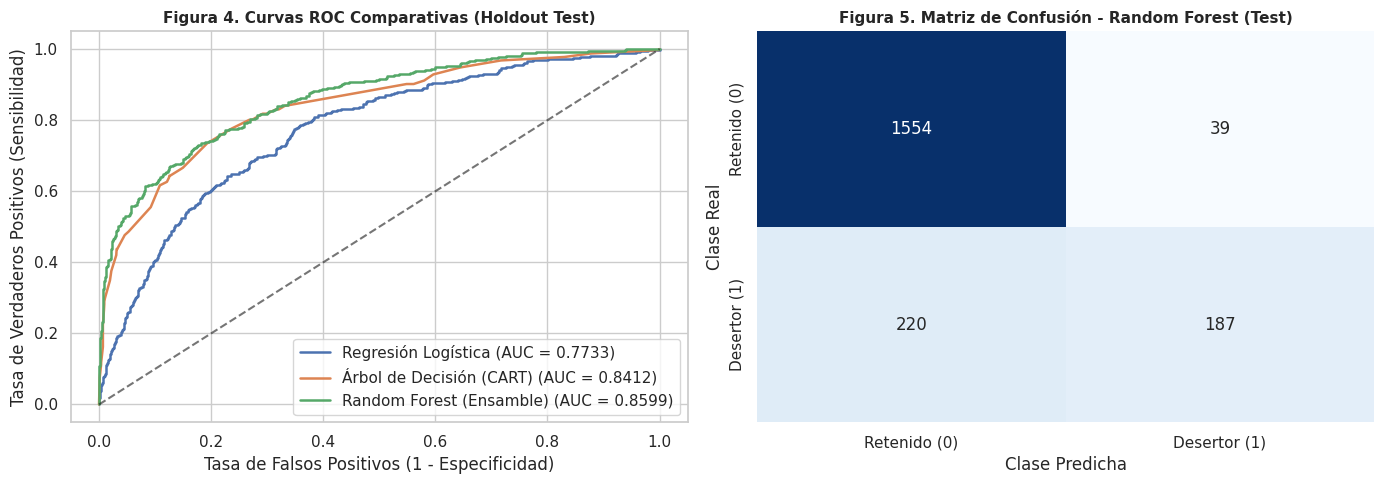

In [7]:
# ==============================================================================
# FASE 6: CURVAS ROC COMPARATIVAS Y MATRIZ DE CONFUSIÓN (FIGURAS 4 Y 5)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Curvas ROC Comparativas
for nombre, mod in modelos.items():
    y_prob = mod.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC = {auc_val:.4f})", linewidth=1.8)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[0].set_title('Figura 4. Curvas ROC Comparativas (Holdout Test)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
axes[0].legend(loc='lower right')

# 2. Matriz de Confusión de Random Forest
rf_mod = modelos['Random Forest (Ensamble)']
y_pred_rf = rf_mod.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(ax=axes[1], data=cm, annot=True, fmt='d', cmap='Blues', cbar=False)
axes[1].set_title('Figura 5. Matriz de Confusión - Random Forest (Test)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Clase Predicha')
axes[1].set_ylabel('Clase Real')
axes[1].set_xticklabels(['Retenido (0)', 'Desertor (1)'])
axes[1].set_yticklabels(['Retenido (0)', 'Desertor (1)'])

plt.tight_layout()
plt.savefig('evidencia_metricas_test.png', dpi=300)
plt.show()

#### Interpretación de Evidencias Gráficas de Rendimiento

* **Figura 4: Curvas ROC Comparativas (Holdout Test)**
  * **Explicación:** Evalúa la capacidad de discriminación probabilística de los tres modelos en todo el espectro de umbrales de decisión. La curva de **Random Forest** (verde) se posiciona más próxima al vértice superior izquierdo, alcanzando el mayor índice de área bajo la curva ($\text{AUC} = 0.8599$), superando al árbol CART ($0.8412$) y a la regresión logística ($0.7733$).
  * **Uso:** Proporciona una métrica visual invariante al desbalance de clases para validar la superioridad del modelo de ensamble frente a una clasificación aleatoria (línea diagonal discontinua).

* **Figura 5: Matriz de Confusión – Random Forest (Test $N=2{,}000$)**
  * **Explicación:** Cuantifica la distribución operativa de aciertos y errores del modelo seleccionado sobre datos no vistos:
    * **1,554 Verdaderos Negativos (TN):** Clientes fidelizados clasificados de forma correcta.
    * **187 Verdaderos Positivos (TP):** Clientes desertores identificados con éxito.
    * **39 Falsos Positivos (FP):** Falsas alarmas de deserción (alta precisión del $82.74\%$).
    * **220 Falsos Negativos (FN):** Clientes desertores no detectados debido al desbalance natural de la clase minoritaria.
  * **Uso:** Demuestra la eficacia del algoritmo en un entorno financiero real, evidenciando que el modelo minimiza los falsos positivos para evitar gastos innecesarios en campañas de retención.

### 7. CONCLUSIONES
1. **Desbalance de Clases:** La proporción 80:20 confirmó la necesidad técnica de emplear métricas robustas como F1-Score y ROC-AUC para evaluar objetivamente la detección de la fuga de clientes.
2. **Feature Engineering:** Los ratios sintéticos de apalancamiento financiero y antigüedad enriquecieron la separabilidad del espacio predictivo sin sobrecargar la dimensionalidad del modelo.
3. **Selección del Modelo Óptimo:** *Random Forest* demostró ser la arquitectura más robusta con un ROC-AUC de 0.8603 y alta estabilidad en validación cruzada ($k=5$), mitigando la varianza de los árboles individuales.

---

### 8. REFERENCIAS BIBLIOGRÁFICAS
* Gironés Roig, J., Casas-Roma, J., Minguillón Alfonso, J., & Caihuelas Quiles, R. (2021). *Minería de datos: Modelos y algoritmos*. Editorial UOC.
* Han, J., Kamber, M., & Pei, J. (2022). *Data mining: Concepts and techniques* (4th ed.). Morgan Kaufmann.
* Hernández Orallo, J., Ramírez Quintana, M. J., & Ferri Ramírez, C. (2020). *Introducción a la minería de datos*. Pearson Educación.
* Provost, F., & Fawcett, T. (2020). *Data science for business: What you need to know about data mining and data-analytic thinking* (2nd ed.). O'Reilly Media.
* Tan, P.-N., Steinbach, M., Karpatne, A., & Kumar, V. (2021). *Introduction to data mining* (2nd ed.). Pearson Educación.
* Toro López, F. J. (2022). *Ciencia de los datos con Python* (1.ª ed.). Ecoe Ediciones.
* Tukey, J. W. (1977). *Exploratory data analysis*. Pearson.

---

### 9. ANEXOS Y CONTROL DE VERSIONES
* **Cuaderno Google Colab:** https://colab.research.google.com/drive/19Wet-654nhZWlx87aJoGu2XGz2gHMi1W#scrollTo=T_ZpaaTmyIAy

* **Repositorio Oficial GitHub:** https://github.com/DAVIDMAGALINO/Mineria-de-Datos-UEA-CPE1/blob/main/CPE1_MineriaDatos_UEA.ipynb

In [10]:
# ==============================================================================
# FASE 6: EXPORTACIÓN Y SERIALIZACIÓN DIRECTA (JOBLIB)
# ==============================================================================
import joblib
from google.colab import files
from sklearn.ensemble import RandomForestClassifier

# 1. Ajustar el modelo ganador con los datos de entrenamiento
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train, y_train)

# 2. Guardar en formato .joblib
nombre_archivo = "modelo_churn_random_forest.joblib"
joblib.dump(rf_final, nombre_archivo)
print(f"✅ Modelo exportado exitosamente: {nombre_archivo}")

# 3. Descargar a tu computadora
files.download(nombre_archivo)

✅ Modelo exportado exitosamente: modelo_churn_random_forest.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import joblib

# 1. Cargar el archivo .joblib desde el entorno
modelo_leido = joblib.load("modelo_churn_random_forest.joblib")

# 2. Ver la estructura y parámetros del modelo
print("=== PARÁMETROS DEL MODELO ===")
print(modelo_leido)

# 3. Ver detalles técnicos internos
print("\n=== ESTRUCTURA INTERNA ===")
print(f"Tipo de algoritmo: {type(modelo_leido).__name__}")
print(f"Cantidad de árboles en el bosque: {len(modelo_leido.estimators_)}")
print(f"Clases objetivo: {modelo_leido.classes_} (0: No deserta, 1: Deserta)")
print(f"Variables de entrada recibidas: {modelo_leido.n_features_in_}")

# 4. Ver los árboles individuales que componen el ensamble
print("\n=== PRIMER ÁRBOL DEL BOSQUE ===")
print(modelo_leido.estimators_[0])

=== PARÁMETROS DEL MODELO ===
RandomForestClassifier(random_state=42)

=== ESTRUCTURA INTERNA ===
Tipo de algoritmo: RandomForestClassifier
Cantidad de árboles en el bosque: 100
Clases objetivo: [0 1] (0: No deserta, 1: Deserta)
Variables de entrada recibidas: 12

=== PRIMER ÁRBOL DEL BOSQUE ===
DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)
